In [44]:
import pandas as pd
import numpy as np

In [45]:
# Read CSV file
df = pd.read_csv('AirQualityUCI.csv')

In [46]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH
0,10-03-2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,10-03-2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,10-03-2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,10-03-2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,10-03-2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   Wind           9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   Solor.R        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  Ozone          9357 non-null   int64  
 12  Temp           9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [48]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'Wind',
       'PT08.S2(NMHC)', 'Solor.R', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'Ozone', 'Temp', 'RH', 'AH'],
      dtype='object')

In [49]:
# Change Datatypes

# Reduce memory usage
df['CO(GT)'] = df['CO(GT)'].astype('float32')
df['Wind'] = df['Wind'].astype('float32')
df['Temp'] = df['Temp'].astype('float32')
df['RH'] = df['RH'].astype('float32')
df['AH'] = df['AH'].astype('float32')

df['Date'] = df['Date'].astype('string')
df['Time'] = df['Time'].astype('string')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   string 
 1   Time           9357 non-null   string 
 2   CO(GT)         9357 non-null   float32
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   Wind           9357 non-null   float32
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   Solor.R        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  Ozone          9357 non-null   int64  
 12  Temp           9357 non-null   float32
 13  RH             9357 non-null   float32
 14  AH             9357 non-null   float32
dtypes: float32(5), int64(8), string(2)
memory usage: 913.9 KB


In [50]:
# Remove Duplicate Rows

df = df.drop_duplicates()

In [51]:
# Check Missing Values

df.isna().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
Wind             0
PT08.S2(NMHC)    0
Solor.R          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
Ozone            0
Temp             0
RH               0
AH               0
dtype: int64

In [52]:
percent_missing = df.isnull().sum() * 100 / len(df)

In [53]:
percent_missing.sort_values(ascending=False)

Date             0.0
Time             0.0
CO(GT)           0.0
PT08.S1(CO)      0.0
NMHC(GT)         0.0
Wind             0.0
PT08.S2(NMHC)    0.0
Solor.R          0.0
PT08.S3(NOx)     0.0
NO2(GT)          0.0
PT08.S4(NO2)     0.0
Ozone            0.0
Temp             0.0
RH               0.0
AH               0.0
dtype: float64

In [54]:
# Seperate Caterogical and Numerical Values

col_var = ['Date', 'Time']

In [55]:
col_num = ['CO(GT)', 'Wind', 'Temp', 'RH', 'AH']

In [56]:
# Fill Missing Values

for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'string':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

In [57]:
df.isna().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
Wind             0
PT08.S2(NMHC)    0
Solor.R          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
Ozone            0
Temp             0
RH               0
AH               0
dtype: int64

In [58]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH
0,10-03-2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.600000,48.900002,0.7578
1,10-03-2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.300000,47.700001,0.7255
2,10-03-2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.900000,54.000000,0.7502
3,10-03-2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.000000,60.000000,0.7867
4,10-03-2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.200000,59.599998,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04-04-2005,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.900000,29.299999,0.7568
9353,04-04-2005,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.299999,23.700001,0.7119
9354,04-04-2005,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.900000,18.299999,0.6406
9355,04-04-2005,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.299999,13.500000,0.5139


In [59]:
# Create Subsets

subSet1 = df[['Date', 'Time']]

In [60]:
subSet2 = df[['Temp', 'RH']]

In [61]:
subSet1.head()

,Date,Time
0,10-03-2004,18:00:00
1,10-03-2004,19:00:00
2,10-03-2004,20:00:00
3,10-03-2004,21:00:00
4,10-03-2004,22:00:00


In [62]:
subSet2.head()

,Temp,RH
0,13.6,48.900002
1,13.3,47.700001
2,11.9,54.000000
3,11.0,60.000000
4,11.2,59.599998


In [63]:
# Concatenate Data Frames

concatenated_df = pd.concat([subSet1, subSet2], axis=1)

In [64]:
concatenated_df

,Date,Time,Temp,RH
0,10-03-2004,18:00:00,13.600000,48.900002
1,10-03-2004,19:00:00,13.300000,47.700001
2,10-03-2004,20:00:00,11.900000,54.000000
3,10-03-2004,21:00:00,11.000000,60.000000
4,10-03-2004,22:00:00,11.200000,59.599998
...,...,...,...,...
9352,04-04-2005,10:00:00,21.900000,29.299999
9353,04-04-2005,11:00:00,24.299999,23.700001
9354,04-04-2005,12:00:00,26.900000,18.299999
9355,04-04-2005,13:00:00,28.299999,13.500000


In [65]:
# Outlier Removal Funation

def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    threshold = 1.5 * IQR
    
    outlier_mask = (column < Q1 - threshold) | (column > Q3 + threshold)
    
    return column[~outlier_mask]

In [66]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'Wind',
       'PT08.S2(NMHC)', 'Solor.R', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'Ozone', 'Temp', 'RH', 'AH'],
      dtype='object')

In [67]:
# Remove Outliers

col_name = ['CO(GT)', 'Wind', 'Temp', 'RH', 'AH']

for col in col_name:
    df[col] = remove_outliers(df[col])

In [68]:
# Visualization

import seaborn as sns
import matplotlib.pyplot as plt

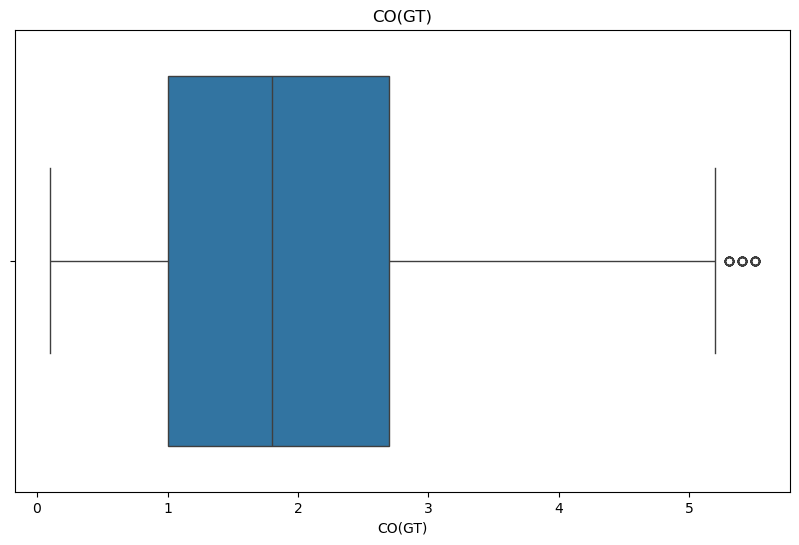

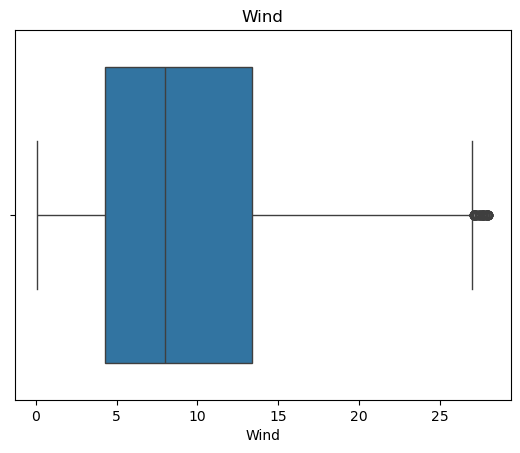

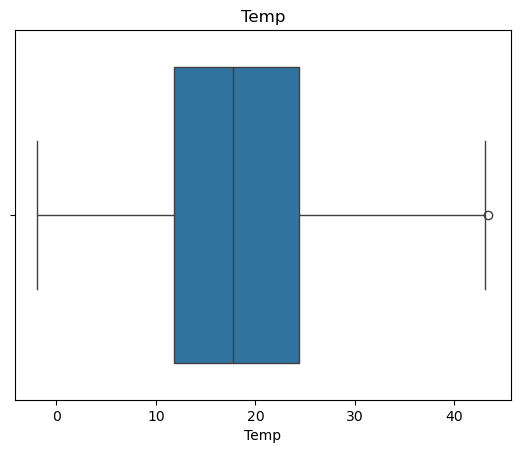

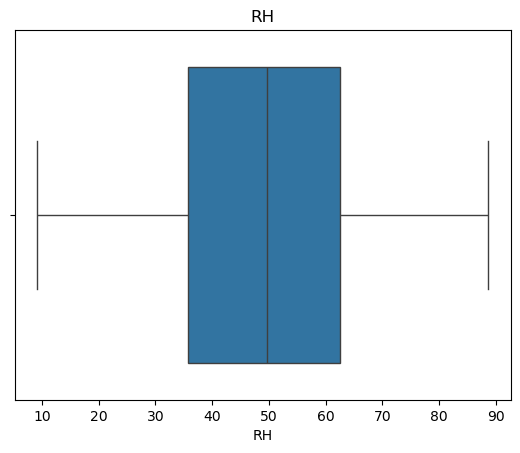

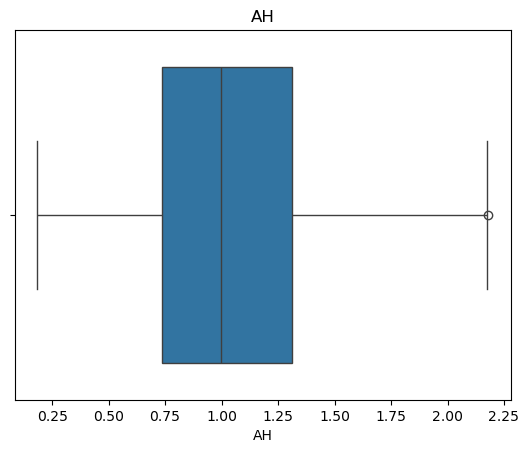

In [69]:
plt.figure(figsize=(10,6))

for col in col_name:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [70]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

In [71]:
col_label = ['Date', 'Time']

encoder = LabelEncoder()

for col in col_label:
    df[col] = encoder.fit_transform(df[col])

In [72]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),Wind,PT08.S2(NMHC),Solor.R,PT08.S3(NOx),NO2(GT),PT08.S4(NO2),Ozone,Temp,RH,AH
0,114,18,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.600000,48.900002,0.7578
1,114,19,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.300000,47.700001,0.7255
2,114,20,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.900000,54.000000,0.7502
3,114,21,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.000000,60.000000,0.7867
4,114,22,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.200000,59.599998,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,43,10,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.900000,29.299999,0.7568
9353,43,11,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.299999,23.700001,0.7119
9354,43,12,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.900000,18.299999,0.6406
9355,43,13,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.299999,13.500000,0.5139
